In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from pathlib import Path
from networkx.algorithms import community
from sklearn.preprocessing import MultiLabelBinarizer
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
data_path = Path("../data/processed/reddit_adr_clean.csv")
out_dir = Path("../data/processed")
out_dir.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(data_path)

## User & ADR co-occurence

In [4]:
user_adr = df.groupby("post_id")["adr"].apply(list)
pairs = Counter()
for adrs in user_adr:
    unique = list(set(adrs))
    for a, b in combinations(unique, 2):
        pairs[(a,b)] += 1

## Community detection

## Filtering weak edges

In [26]:
pair_weights = [w for (_, _), w in pairs.items()]
threshold = 2
print(f"Edge weight threshold: ≥{threshold:.0f}")

Edge weight threshold: ≥2


## Graphs

In [27]:
G = nx.Graph()
for (a, b), w in pairs.items():
    if w >= threshold:
        G.add_edge(a, b, weight=w)
print(f"Filtered graph → Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

Filtered graph → Nodes: 58, Edges: 105


In [28]:
low_deg = [n for n, d in dict(G.degree()).items() if d <= 1]
G.remove_nodes_from(low_deg)
print(f"After pruning → Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

After pruning → Nodes: 38, Edges: 87


In [29]:
from networkx.algorithms import community
communities = community.greedy_modularity_communities(G)
print(f"Detected {len(communities)} communities after filtering")


Detected 7 communities after filtering


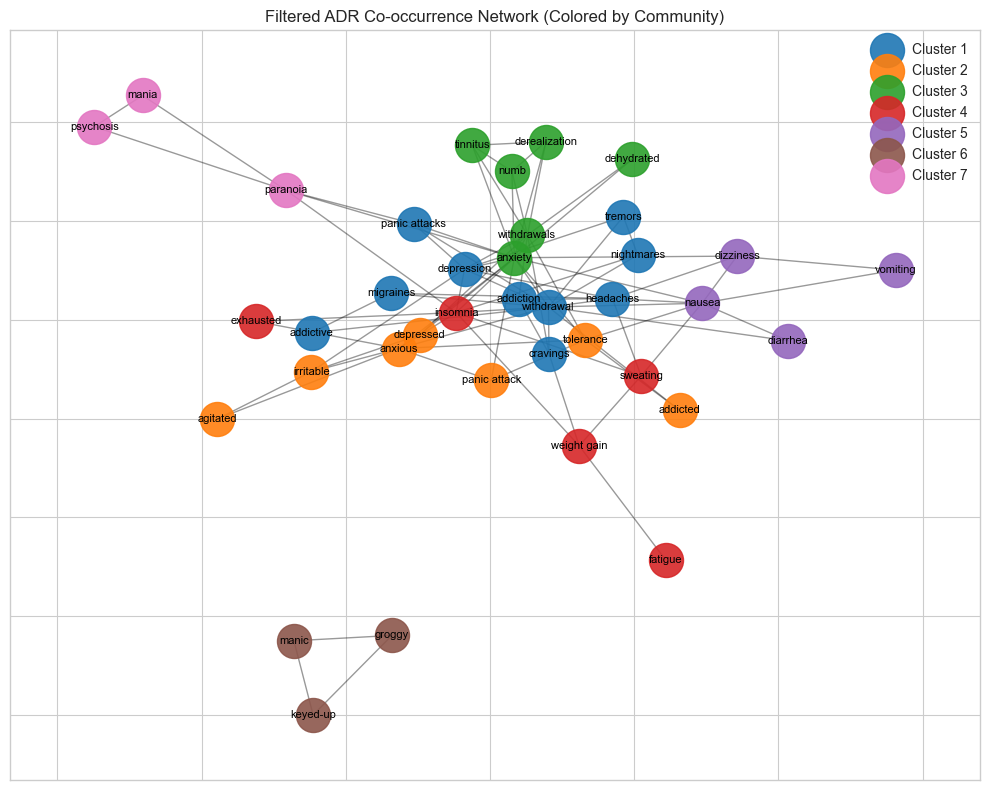

In [30]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

colors = list(mcolors.TABLEAU_COLORS.values())
pos = nx.spring_layout(G, k=0.5, seed=42)

plt.figure(figsize=(10,8))
for i, com in enumerate(communities):
    nx.draw_networkx_nodes(G, pos, nodelist=list(com),
                           node_color=colors[i % len(colors)], label=f"Cluster {i+1}",
                           node_size=600, alpha=0.9)
nx.draw_networkx_edges(G, pos, alpha=0.4)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.legend()
plt.title("Filtered ADR Co-occurrence Network (Colored by Community)")
plt.tight_layout()
plt.savefig(out_dir / "fig_adr_network_filtered.png", dpi=300)
plt.show()

## Correlation heatmap

In [32]:
mlb = MultiLabelBinarizer()
user_adr_matrix = pd.DataFrame(
    mlb.fit_transform(user_adr),
    index=user_adr.index, columns=mlb.classes_
)

# Keeping only ADRs present in the filtered graph(with the threshold)
filtered_adrs = list(G.nodes())
user_adr_matrix = user_adr_matrix[filtered_adrs]
corr = user_adr_matrix.corr()

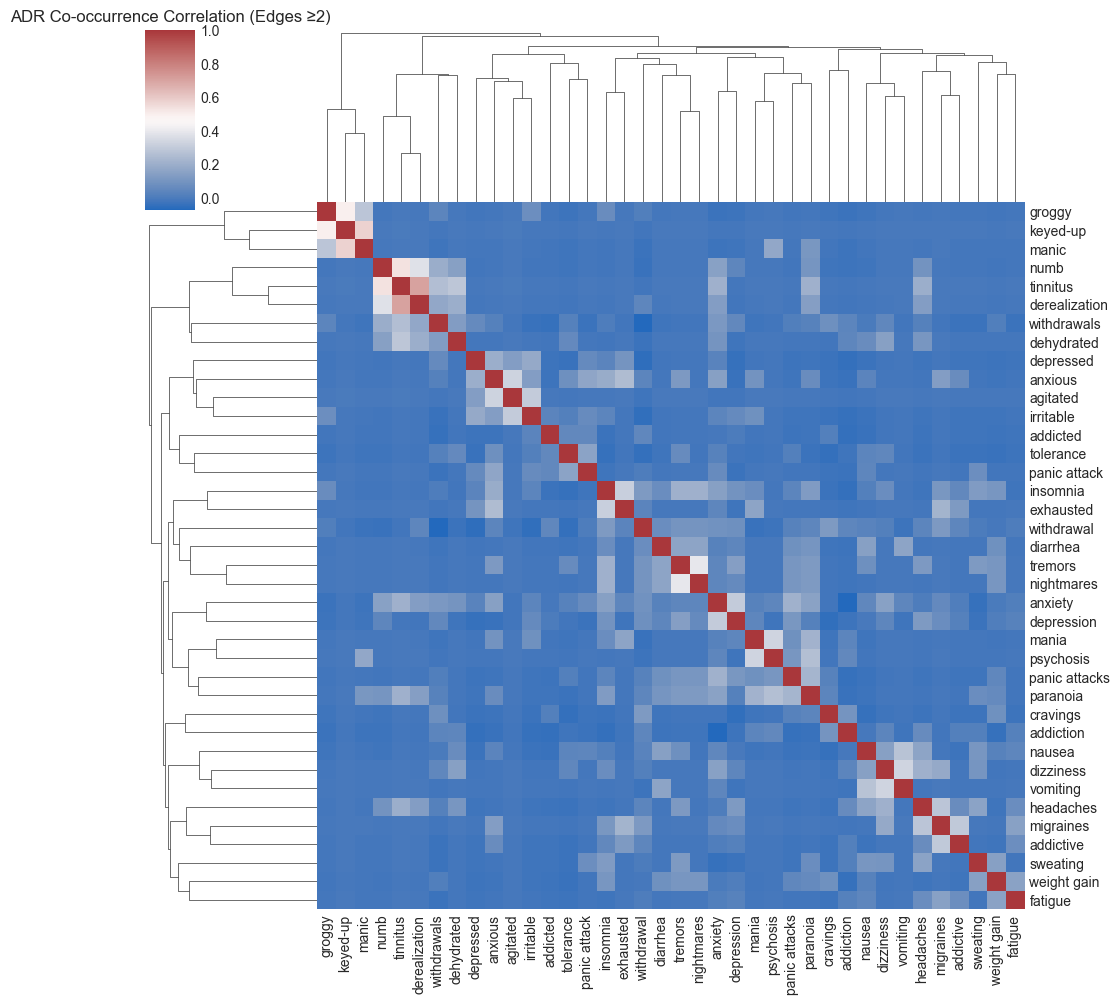

In [33]:
sns.clustermap(corr, cmap="vlag", figsize=(10,10))
plt.title(f"ADR Co-occurrence Correlation (Edges ≥{threshold})")
plt.savefig(out_dir / f"fig_adr_heatmap_cutoff_{threshold}.png", dpi=300)

In [34]:
cluster_summary = []
for i, com in enumerate(communities):
    for adr in com:
        cluster_summary.append({"cluster": i+1, "adr": adr, "degree": G.degree(adr)})
cluster_df = pd.DataFrame(cluster_summary).sort_values(["cluster", "degree"], ascending=[True, False])
cluster_df.to_csv(out_dir / f"adr_clusters_cutoff_{threshold}.csv", index=False)
print("Saved:", out_dir / f"adr_clusters_cutoff_{threshold}.csv")   

Saved: ../data/processed/adr_clusters_cutoff_2.csv


## Symptom similarity co-occurence

In [35]:
adj = nx.to_numpy_array(G)
nodes = list(G.nodes())

In [36]:
# Normalize for readability
sim_matrix = adj / adj.max()

Saved: ../data/processed/fig_symptom_similarity_cutoff_2.png


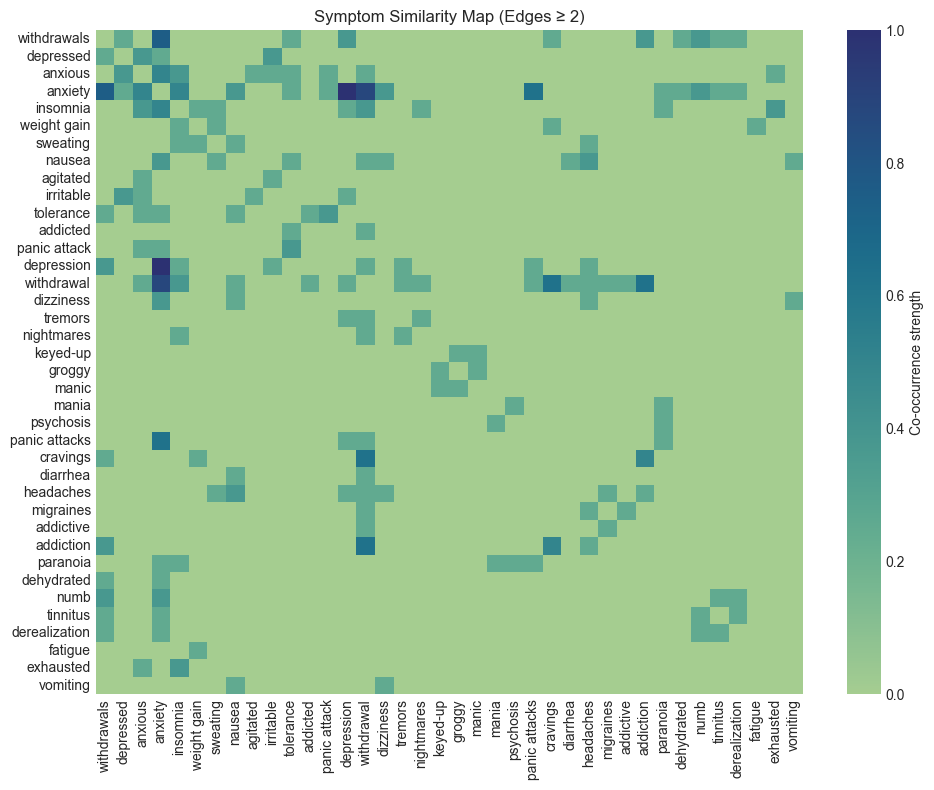

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    xticklabels=nodes,
    yticklabels=nodes,
    cmap="crest",
    cbar_kws={"label": "Co-occurrence strength"}
)
plt.title(f"Symptom Similarity Map (Edges ≥ {threshold})", fontsize=12)
plt.tight_layout()

# SAVE figure
plt.savefig(out_dir / f"fig_symptom_similarity_cutoff_{threshold}.png", dpi=300)
print("Saved:", out_dir / f"fig_symptom_similarity_cutoff_{threshold}.png")

plt.show()